# Limpieza y consulta de datos — Órdenes de producción

**Ciencia de Datos · Corte 2 · Semana 9** · Ingeniería Industrial · CORHUILA

Caso del Corte 1: *predicción de retrasos en órdenes de producción*. Este cuaderno carga el extracto del ERP
(`data/ordenes_produccion_raw.csv`, dataset **sintético** creado con `generar_datos.py`), mide su calidad,
lo limpia paso a paso, demuestra la mejora (antes/después) y responde dos preguntas con pandas **y** SQL.

Reglas del negocio usadas para validar: capacidad máxima de **2 000 unidades por orden**; defectuosas entre
**0 y las producidas**; sensor de temperatura entre **15 y 60 °C**; **4 máquinas, 5 productos y 3 turnos**;
la fecha real de fin no puede ser anterior a la de inicio.

## 1. Carga y primera mirada

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
Path("img").mkdir(exist_ok=True)
Path("data/normalizado").mkdir(parents=True, exist_ok=True)

raw = pd.read_csv("data/ordenes_produccion_raw.csv")
print("Filas x columnas:", raw.shape)
raw.head(8)

Filas x columnas: (438, 13)


,id_orden,fecha_inicio,fecha_fin_plan,fecha_fin_real,maquina,producto,turno,cant_plan,cant_prod,defectuosas,horas_parada,mp_disponible,temperatura
0,OP-0383,2026-03-31,2026-04-06,2026-04-08,m4,p-03,Noche,1600,1544,28.0,0.6,No,30.5
1,OP-0398,2026-07-28,2026-08-03,02/08/2026,M-02,P-01,Tarde,500,472,7.0,1.1,si,33.2
2,OP-0352,2026-07-28,2026-08-03,2026-08-04,M-01,P-01,Tarde,1100,1063,16.0,0.0,Si,33.4
3,OP-0391,2026-04-28,2026-04-30,2026-04-30,M-03,P-03,Mañana,1300,1287,57.0,1.0,Sí,"34,3"
4,OP-0200,2026-07-29,31/07/2026,2026-08-01,M-02,p-01,Mañana,1100,1066,10.0,"5,5",SI,34.3
5,OP-0171,2026-04-23,2026-04-28,30/04/2026,m-02,P-01,noche,1200,1135,11.0,"5,3",Sí,"30,0"
6,OP-0394,2026-06-11,2026-06-14,2026-06-20,M-3,P-04,Tarde,1600,1584,63.0,16.2,No,"33,3"
7,OP-0054,2026-06-01,2026-06-04,2026-06-05,M-03,P-05,Mañana,1600,1517,70.0,"4,5",si,"35,6"


In [2]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 438 entries, 0 to 437
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_orden        438 non-null    str    
 1   fecha_inicio    438 non-null    str    
 2   fecha_fin_plan  438 non-null    str    
 3   fecha_fin_real  427 non-null    str    
 4   maquina         438 non-null    str    
 5   producto        438 non-null    str    
 6   turno           438 non-null    str    
 7   cant_plan       438 non-null    int64  
 8   cant_prod       438 non-null    int64  
 9   defectuosas     425 non-null    float64
 10  horas_parada    416 non-null    str    
 11  mp_disponible   428 non-null    str    
 12  temperatura     426 non-null    str    
dtypes: float64(1), int64(2), str(10)
memory usage: 44.6 KB


`info()` ya delata problemas: `horas_parada` y `temperatura` son **texto** (llevan coma decimal), las tres
fechas también son texto y `defectuosas` es decimal porque tiene vacíos.

## 2. Diagnóstico ANTES de limpiar

In [3]:
# 2.1 Nulos por columna
nulos_antes = raw.isnull().sum()
pd.DataFrame({"nulos": nulos_antes, "% nulos": (nulos_antes / len(raw) * 100).round(1)})

,nulos,% nulos
id_orden,0,0.0
fecha_inicio,0,0.0
fecha_fin_plan,0,0.0
fecha_fin_real,11,2.5
maquina,0,0.0
producto,0,0.0
turno,0,0.0
cant_plan,0,0.0
cant_prod,0,0.0
defectuosas,13,3.0


In [4]:
# 2.2 Duplicados y cuántas formas de escribir cada catálogo
print("Filas duplicadas exactas:", raw.duplicated().sum())
print("IDs de orden repetidos  :", raw["id_orden"].duplicated().sum())
for c in ["maquina", "producto", "turno", "mp_disponible"]:
    print(f"{c:14s} -> {raw[c].nunique():2d} formas distintas:", sorted(raw[c].dropna().unique())[:8], "...")

Filas duplicadas exactas: 18
IDs de orden repetidos  : 18
maquina        -> 24 formas distintas: [' M-01 ', ' M-02', ' m-04 ', 'M 03', 'M-01', 'M-02', 'M-03', 'M-03 '] ...
producto       -> 25 formas distintas: [' P-01', ' P-02', ' P-03', ' P-04', ' P-05', 'P-01', 'P-01 ', 'P-02'] ...
turno          -> 18 formas distintas: [' Tarde', ' mañana', ' noche', 'MAÑANA', 'Manana', 'Mañana', 'Mañana ', 'NOCHE'] ...
mp_disponible  -> 10 formas distintas: ['N', 'NO', 'No', 'No ', 'S', 'SI', 'Si ', 'Sí'] ...


In [5]:
CATALOGO = {
    "maquina":  {"M-01", "M-02", "M-03", "M-04"},
    "producto": {"P-01", "P-02", "P-03", "P-04", "P-05"},
    "turno":    {"Mañana", "Tarde", "Noche"},
    "mp_disponible": {"Sí", "No", "Sin dato"},
}
REQUERIDAS = [c for c in raw.columns if c != "fecha_fin_real"]  # fecha_fin_real vacía = orden en curso (válido)
RX_ISO = r"^\d{4}-\d{2}-\d{2}$"


def _num(s):
    """Serie -> número, tolerando coma decimal. Lo no interpretable queda NaN."""
    if pd.api.types.is_numeric_dtype(s):
        return s
    return pd.to_numeric(s.astype("string").str.replace(",", ".", regex=False), errors="coerce")


def _fecha(s):
    """Serie -> fecha, probando aaaa-mm-dd y dd/mm/aaaa por separado (sin adivinar)."""
    if pd.api.types.is_datetime64_any_dtype(s):
        return s
    s = s.astype("string")
    iso = pd.to_datetime(s, format="%Y-%m-%d", errors="coerce")
    dmy = pd.to_datetime(s, format="%d/%m/%Y", errors="coerce")
    return iso.fillna(dmy)


def _todos(lista):
    """% de filas donde TODAS las condiciones (Series booleanas) se cumplen."""
    return np.logical_and.reduce([pd.Series(x).fillna(False).astype(bool).to_numpy() for x in lista]).mean()


def reporte_calidad(t):
    """% de filas que cumplen cada dimensión de calidad (sirve para antes y después)."""
    # Completitud: sin vacíos en las columnas obligatorias
    completitud = t[REQUERIDAS].notna().all(axis=1).mean()
    # Unicidad: fila no repetida y un solo registro por orden
    unicidad = (~t.duplicated() & ~t["id_orden"].duplicated()).mean()
    # Consistencia: los catálogos se escriben exactamente como el catálogo oficial
    consistencia = np.logical_and.reduce([t[c].isin(v) for c, v in CATALOGO.items()]).mean() \
        if all(c in t for c in CATALOGO) else np.nan
    # Formato: fechas aaaa-mm-dd (o datetime) y números sin coma decimal
    ok_fecha = []
    for c in ["fecha_inicio", "fecha_fin_plan", "fecha_fin_real"]:
        if pd.api.types.is_datetime64_any_dtype(t[c]):
            ok_fecha.append(pd.Series(True, index=t.index))
        else:
            ok_fecha.append(t[c].isna() | t[c].astype("string").str.match(RX_ISO).fillna(False))
    ok_num = [pd.Series(True, index=t.index) if pd.api.types.is_numeric_dtype(t[c])
              else ~t[c].astype("string").str.contains(",", regex=False).fillna(False)
              for c in ["horas_parada", "temperatura"]]
    formato = _todos(ok_fecha + ok_num)
    # Validez: reglas del negocio (un vacío no viola la regla; eso lo mide la completitud)
    cp, df_, tmp, hp = _num(t["cant_prod"]), _num(t["defectuosas"]), _num(t["temperatura"]), _num(t["horas_parada"])
    fi, ffr = _fecha(t["fecha_inicio"]), _fecha(t["fecha_fin_real"])
    reglas = [
        (cp.isna() | (cp <= 2000)),
        (df_.isna() | ((df_ >= 0) & (df_ <= cp))),
        (tmp.isna() | tmp.between(15, 60)),
        (hp.isna() | (hp >= 0)),
        (ffr.isna() | (ffr >= fi)),
    ]
    validez = _todos(reglas)
    return (pd.Series({"Completitud": completitud, "Unicidad": unicidad, "Consistencia": consistencia,
                       "Formato": formato, "Validez": validez}) * 100).round(1)


calidad_antes = reporte_calidad(raw)   # los textos tal como llegaron
calidad_antes

Completitud     87.7
Unicidad        95.9
Consistencia     8.0
Formato         24.0
Validez         94.3
dtype: float64

In [6]:
# 2.3 Cuántas filas rompen cada regla del negocio (sobre los datos crudos, ya interpretados)
cp, de, tm, ffr, fi = _num(raw["cant_prod"]), _num(raw["defectuosas"]), _num(raw["temperatura"]), _fecha(raw["fecha_fin_real"]), _fecha(raw["fecha_inicio"])
print("cant_prod > 2000                :", (cp > 2000).sum())
print("defectuosas > producidas        :", (de > cp).sum())
print("defectuosas negativas           :", (de < 0).sum())
print("temperatura > 60 (probable °F)  :", (tm > 60).sum())
print("fecha_fin_real < fecha_inicio   :", (ffr < fi).sum())
print("Fechas que no se pudieron leer  :", int(_fecha(raw["fecha_inicio"]).isna().sum() + _fecha(raw["fecha_fin_plan"]).isna().sum()))
print("Fechas en dd/mm/aaaa            :", int(raw[["fecha_inicio","fecha_fin_plan","fecha_fin_real"]].apply(lambda c: c.astype("string").str.contains("/")).sum().sum()))
print("Números con coma decimal        :", int(raw[["horas_parada","temperatura"]].apply(lambda c: c.astype("string").str.contains(",")).sum().sum()))

cant_prod > 2000                : 2
defectuosas > producidas        : 3
defectuosas negativas           : 2
temperatura > 60 (probable °F)  : 14
fecha_fin_real < fecha_inicio   : 5
Fechas que no se pudieron leer  : 0
Fechas en dd/mm/aaaa            : 225
Números con coma decimal        : 321


## 3. Limpieza paso a paso

Se trabaja sobre una **copia** (`limpio`) para no tocar el original, y cada paso se anota en una **bitácora**
(filas antes/después y cuántos valores se corrigieron). El orden importa: primero duplicados, luego textos,
tipos, unidades, faltantes y por último imposibles.

In [7]:
limpio = raw.copy()
bitacora = []


def registrar(paso, accion, antes, despues, corregidos=0, nota=""):
    bitacora.append({"Paso": paso, "Acción": accion, "Filas antes": antes,
                     "Filas después": despues, "Valores corregidos": corregidos, "Nota": nota})

**Paso 1 · Quitar duplicados** (copiar y pegar). Antes de sumar o promediar, cada orden debe contar una vez.

In [8]:
antes = len(limpio)
limpio = limpio.drop_duplicates().reset_index(drop=True)
registrar(1, "Quitar duplicados exactos", antes, len(limpio), 0, "copias por copiar/pegar")
print(antes, "->", len(limpio), "| IDs repetidos que quedan:", limpio["id_orden"].duplicated().sum())

438 -> 420 | IDs repetidos que quedan: 0


**Paso 2 · Homologar textos.** Para una persona `' m-03 '`, `M3` y `M-03` son lo mismo; para Python no.
Se limpian espacios/mayúsculas y se reescribe cada valor con el código oficial del catálogo.

In [9]:
n_formas = {c: limpio[c].nunique() for c in ["maquina", "producto", "turno", "mp_disponible"]}
orig = limpio[["maquina", "producto", "turno", "mp_disponible"]].copy()

# Máquina y producto: se toma el último dígito del código y se reconstruye 'M-0X' / 'P-0X'
for col, pref in [("maquina", "M"), ("producto", "P")]:
    d = limpio[col].str.extract(r"(\d)\D*$")[0]
    limpio[col] = pref + "-0" + d

# Turno: sin espacios, minúsculas, y 'manana' -> 'Mañana'
limpio["turno"] = (limpio["turno"].str.strip().str.lower()
                   .replace({"manana": "mañana"}).str.capitalize())

# Disponibilidad de materia prima: Sí / No / Sin dato (el vacío NO se inventa)
mp = limpio["mp_disponible"].str.strip().str.lower()
limpio["mp_disponible"] = (mp.map({"si": "Sí", "sí": "Sí", "s": "Sí", "no": "No", "n": "No"})
                           .fillna("Sin dato"))

corr = int((orig != limpio[orig.columns]).any(axis=1).sum())
registrar(2, "Homologar máquina/producto/turno/materia prima", len(limpio), len(limpio), corr,
          "espacios, mayúsculas, M3 -> M-03, si/S -> Sí")
print("Formas distintas antes :", n_formas)
print("Formas distintas después:", {c: limpio[c].nunique() for c in n_formas})
for c in CATALOGO:
    assert set(limpio[c].unique()) <= CATALOGO[c], c

Formas distintas antes : {'maquina': 24, 'producto': 25, 'turno': 18, 'mp_disponible': 10}
Formas distintas después: {'maquina': 4, 'producto': 5, 'turno': 3, 'mp_disponible': 3}


**Paso 3 · Tipos correctos.** Números con coma decimal -> `float`; fechas -> `datetime` leyendo cada formato
por separado (si pandas adivina, `07/09` puede ser 9 de julio sin avisar). Se cuentan los vacíos antes y después
para comprobar que `errors="coerce"` no borró nada.

In [10]:
for col in ["horas_parada", "temperatura"]:
    v0 = limpio[col].isna().sum()
    limpio[col] = pd.to_numeric(limpio[col].astype("string").str.replace(",", ".", regex=False), errors="coerce")
    assert limpio[col].isna().sum() == v0, "coerce creó vacíos nuevos"
n_num = int(raw.drop_duplicates()[["horas_parada", "temperatura"]].apply(lambda c: c.astype("string").str.contains(",")).sum().sum())

n_fec = 0
for col in ["fecha_inicio", "fecha_fin_plan", "fecha_fin_real"]:
    s = limpio[col].astype("string")
    v0 = s.isna().sum()
    n_fec += int(s.str.contains("/").sum())
    limpio[col] = _fecha(s)
    assert limpio[col].isna().sum() == v0, f"fechas sin interpretar en {col}"

limpio["cant_plan"] = limpio["cant_plan"].astype(int)
limpio["cant_prod"] = limpio["cant_prod"].astype(int)
registrar(3, "Texto -> número (coma decimal) y texto -> fecha", len(limpio), len(limpio), n_num + n_fec,
          f"{n_num} números con coma, {n_fec} fechas dd/mm/aaaa")
limpio.dtypes

id_orden                     str
fecha_inicio      datetime64[us]
fecha_fin_plan    datetime64[us]
fecha_fin_real    datetime64[us]
maquina                      str
producto                     str
turno                        str
cant_plan                  int32
cant_prod                  int32
defectuosas              float64
horas_parada             Float64
mp_disponible                str
temperatura              Float64
dtype: object

**Paso 4 · Unidades mezcladas.** Ninguna máquina trabaja a más de 60 °C; todo valor mayor está en °F
y se convierte con `(F − 32) × 5/9` **solo en las filas marcadas**.

In [11]:
en_f = limpio["temperatura"] > 60
print("Lecturas en °F:", en_f.sum(), "| rango antes:", limpio.loc[en_f, "temperatura"].min(), "-", limpio.loc[en_f, "temperatura"].max())
limpio.loc[en_f, "temperatura"] = ((limpio.loc[en_f, "temperatura"] - 32) * 5 / 9).round(1)
print("Rango después :", limpio.loc[en_f, "temperatura"].min(), "-", limpio.loc[en_f, "temperatura"].max())
registrar(4, "Lecturas °F -> °C", len(limpio), len(limpio), int(en_f.sum()), "temperatura > 60 °C")

Lecturas en °F: 13 | rango antes: 85.8 - 96.3
Rango después : 29.9 - 35.7


**Paso 5 · Faltantes: eliminar o imputar.** La decisión depende del papel de cada columna:

| Columna | Vacíos | Decisión | Por qué |
|---|---|---|---|
| `defectuosas` | medida real de calidad | **Eliminar fila** | rellenarla sería inventar defectos |
| `horas_parada`, `temperatura` | variables de apoyo | **Imputar con la mediana de su máquina** + bandera `*_imputada` | la mediana resiste extremos y lo estimado no se confunde con lo medido |
| `mp_disponible` | no se puede inferir | **Categoría `Sin dato`** (ya aplicada) | evita suponer que hubo o no materia prima |
| `fecha_fin_real` | orden aún en curso | **Se conserva vacía** | no es un error: la orden no ha terminado |

In [12]:
antes = len(limpio)
limpio = limpio.dropna(subset=["defectuosas"]).reset_index(drop=True)
limpio["defectuosas"] = limpio["defectuosas"].astype(int)
registrar("5a", "Eliminar filas sin 'defectuosas'", antes, len(limpio), 0, "no se inventan defectos")

imputados = 0
for col in ["horas_parada", "temperatura"]:
    limpio[f"{col}_imputada"] = limpio[col].isna()
    mediana = limpio.groupby("maquina")[col].transform("median")
    limpio[col] = limpio[col].fillna(mediana)
    imputados += int(limpio[f"{col}_imputada"].sum())
registrar("5b", "Imputar horas_parada y temperatura (mediana por máquina)", len(limpio), len(limpio), imputados, "con bandera *_imputada")
print("Órdenes en curso (fecha_fin_real vacía, se conservan):", limpio["fecha_fin_real"].isna().sum())
print("Materia prima 'Sin dato':", (limpio["mp_disponible"] == "Sin dato").sum())

Órdenes en curso (fecha_fin_real vacía, se conservan): 9
Materia prima 'Sin dato': 8


**Paso 6 · Valores imposibles ≠ atípicos.** Un valor *imposible* viola una regla del negocio (se elimina y se anota);
un *atípico* es raro pero posible (se investiga, no se borra).

In [13]:
antes = len(limpio)
reglas = pd.DataFrame({
    "sobre_capacidad (>2000)": limpio["cant_prod"] > 2000,
    "defectuosas > producidas": limpio["defectuosas"] > limpio["cant_prod"],
    "defectuosas negativas": limpio["defectuosas"] < 0,
    "fin real antes del inicio": limpio["fecha_fin_real"] < limpio["fecha_inicio"],
})
print(reglas.sum().to_string())
imposible = reglas.any(axis=1)
limpio = limpio[~imposible].reset_index(drop=True)
registrar(6, "Eliminar valores imposibles", antes, len(limpio), 0, f"{int(imposible.sum())} filas violan reglas")

sobre_capacidad (>2000)      2
defectuosas > producidas     3
defectuosas negativas        2
fin real antes del inicio    5


In [14]:
# Paso 6b · Atípicos por IQR (se reportan, NO se borran): horas de parada
q1, q3 = limpio["horas_parada"].quantile([.25, .75])
lim_sup = q3 + 1.5 * (q3 - q1)
atipicos = limpio[limpio["horas_parada"] > lim_sup]
print(f"Q1={q1:.1f}  Q3={q3:.1f}  límite superior={lim_sup:.1f} h -> {len(atipicos)} paradas atípicas")
print(atipicos["maquina"].value_counts().to_string())

Q1=1.1  Q3=4.0  límite superior=8.5 h -> 20 paradas atípicas
maquina
M-03    18
M-01     2


Las paradas largas son posibles y se concentran en una máquina: son **la noticia**, no un error, así que se conservan.
Por último se crea la variable objetivo del caso (retraso) y se revisa que no queden duplicados tras homologar.

In [15]:
limpio["dias_retraso"] = (limpio["fecha_fin_real"] - limpio["fecha_fin_plan"]).dt.days
limpio["retrasada"] = np.where(limpio["fecha_fin_real"].notna(), (limpio["dias_retraso"] > 0).astype(float), np.nan)
assert limpio["id_orden"].is_unique and not limpio.duplicated().any()
limpio = limpio.rename(columns={"temperatura": "temperatura_c"})
limpio.head()

,id_orden,fecha_inicio,fecha_fin_plan,fecha_fin_real,maquina,producto,turno,cant_plan,cant_prod,defectuosas,horas_parada,mp_disponible,temperatura_c,horas_parada_imputada,temperatura_imputada,dias_retraso,retrasada
0,OP-0383,2026-03-31,2026-04-06,2026-04-08,M-04,P-03,Noche,1600,1544,28,0.6,No,30.5,False,False,2.0,1.0
1,OP-0398,2026-07-28,2026-08-03,2026-08-02,M-02,P-01,Tarde,500,472,7,1.1,Sí,33.2,False,False,-1.0,0.0
2,OP-0352,2026-07-28,2026-08-03,2026-08-04,M-01,P-01,Tarde,1100,1063,16,0.0,Sí,33.4,False,False,1.0,1.0
3,OP-0391,2026-04-28,2026-04-30,2026-04-30,M-03,P-03,Mañana,1300,1287,57,1.0,Sí,34.3,False,False,0.0,0.0
4,OP-0200,2026-07-29,2026-07-31,2026-08-01,M-02,P-01,Mañana,1100,1066,10,5.5,Sí,34.3,False,False,1.0,1.0


## 4. Resultado: reporte ANTES / DESPUÉS

In [16]:
# Para medir 'después' con la misma función se vuelve a nombrar la columna
calidad_despues = reporte_calidad(limpio.rename(columns={"temperatura_c": "temperatura"}))
comparacion = pd.DataFrame({"Antes (%)": calidad_antes, "Después (%)": calidad_despues})
comparacion["Mejora (pp)"] = (comparacion["Después (%)"] - comparacion["Antes (%)"]).round(1)
comparacion

,Antes (%),Después (%),Mejora (pp)
Completitud,87.7,100.0,12.3
Unicidad,95.9,100.0,4.1
Consistencia,8.0,100.0,92.0
Formato,24.0,100.0,76.0
Validez,94.3,100.0,5.7


In [17]:
nulos_despues = limpio[[c for c in limpio.columns if not c.endswith("_imputada")]].isnull().sum()
resumen = pd.DataFrame({
    "Métrica": ["Filas", "Filas duplicadas", "Formas de escribir 'máquina'", "Formas de escribir 'turno'",
                "Nulos defectuosas", "Nulos horas_parada", "Nulos temperatura", "Nulos mp_disponible",
                "Nulos fecha_fin_real (en curso)"],
    "Antes": [len(raw), raw.duplicated().sum(), raw["maquina"].nunique(), raw["turno"].nunique(),
              nulos_antes["defectuosas"], nulos_antes["horas_parada"], nulos_antes["temperatura"],
              nulos_antes["mp_disponible"], nulos_antes["fecha_fin_real"]],
    "Después": [len(limpio), limpio.duplicated().sum(), limpio["maquina"].nunique(), limpio["turno"].nunique(),
                nulos_despues["defectuosas"], nulos_despues["horas_parada"], nulos_despues["temperatura_c"],
                (limpio["mp_disponible"] == "Sin dato").sum(), nulos_despues["fecha_fin_real"]],
})
resumen

,Métrica,Antes,Después
0,Filas,438,395
1,Filas duplicadas,18,0
2,Formas de escribir 'máquina',24,4
3,Formas de escribir 'turno',18,3
4,Nulos defectuosas,13,0
5,Nulos horas_parada,22,0
6,Nulos temperatura,12,0
7,Nulos mp_disponible,10,8
8,Nulos fecha_fin_real (en curso),11,9


In [18]:
pd.DataFrame(bitacora)

,Paso,Acción,Filas antes,Filas después,Valores corregidos,Nota
0,1,Quitar duplicados exactos,438,420,0,copias por copiar/pegar
1,2,Homologar máquina/producto/turno/materia prima,420,420,386,"espacios, mayúsculas, M3 -> M-03, si/S -> Sí"
2,3,Texto -> número (coma decimal) y texto -> fecha,420,420,530,"311 números con coma, 219 fechas dd/mm/aaaa"
3,4,Lecturas °F -> °C,420,420,13,temperatura > 60 °C
4,5a,Eliminar filas sin 'defectuosas',420,407,0,no se inventan defectos
5,5b,Imputar horas_parada y temperatura (mediana po...,407,407,34,con bandera *_imputada
6,6,Eliminar valores imposibles,407,395,0,12 filas violan reglas


In [19]:
print("Tipos después de limpiar:")
limpio.dtypes.to_frame("dtype")

Tipos después de limpiar:


,dtype
id_orden,str
fecha_inicio,datetime64[us]
fecha_fin_plan,datetime64[us]
fecha_fin_real,datetime64[us]
maquina,str
producto,str
turno,str
cant_plan,int32
cant_prod,int32
defectuosas,int32


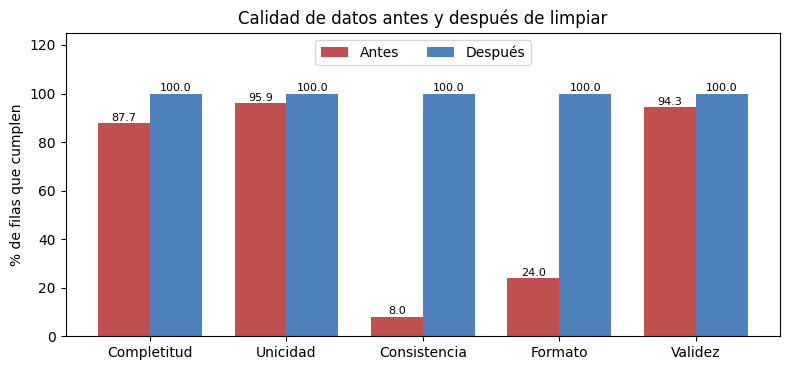

In [20]:
fig, ax = plt.subplots(figsize=(8, 3.8))
x = np.arange(len(comparacion)); w = 0.38
ax.bar(x - w/2, comparacion["Antes (%)"], w, label="Antes", color="#c0504d")
ax.bar(x + w/2, comparacion["Después (%)"], w, label="Después", color="#4f81bd")
ax.set_xticks(x); ax.set_xticklabels(comparacion.index); ax.set_ylim(0, 125); ax.set_ylabel("% de filas que cumplen")
ax.set_title("Calidad de datos antes y después de limpiar"); ax.legend(loc="upper center", ncol=2)
for i, (a, d) in enumerate(zip(comparacion["Antes (%)"], comparacion["Después (%)"])):
    ax.text(i - w/2, a + 1, f"{a:.1f}", ha="center", fontsize=8); ax.text(i + w/2, d + 1, f"{d:.1f}", ha="center", fontsize=8)
plt.tight_layout(); plt.savefig("img/calidad_antes_despues.png", dpi=150); plt.show()

## 5. Datos listos y tablas normalizadas (según el ERD)

Se guarda el CSV limpio y se separa en las tablas del modelo relacional (`esquema_produccion.sql`) para consultarlas
también con SQL.

In [21]:
limpio.to_csv("data/ordenes_produccion_clean.csv", index=False)

maquinas = pd.DataFrame({"id_maquina": ["M-01", "M-02", "M-03", "M-04"],
                         "nombre": ["Extrusora A", "Extrusora B", "Selladora C", "Cortadora D"],
                         "linea": ["Línea 1", "Línea 1", "Línea 2", "Línea 2"],
                         "anio_instalacion": [2019, 2021, 2012, 2023]})
productos = pd.DataFrame({"id_producto": ["P-01", "P-02", "P-03", "P-04", "P-05"],
                          "nombre": ["Película estirable", "Película termoencogible", "Bolsa sellada",
                                     "Bolsa troquelada", "Rollo cortado"],
                          "linea": ["Línea 1", "Línea 1", "Línea 2", "Línea 2", "Línea 2"]})
turnos = pd.DataFrame({"id_turno": [1, 2, 3], "nombre": ["Mañana", "Tarde", "Noche"],
                       "hora_inicio": ["06:00", "14:00", "22:00"], "hora_fin": ["14:00", "22:00", "06:00"]})
ordenes = (limpio.merge(turnos[["id_turno", "nombre"]], left_on="turno", right_on="nombre")
           .rename(columns={"maquina": "id_maquina", "producto": "id_producto"})
           [["id_orden", "id_maquina", "id_producto", "id_turno", "fecha_inicio", "fecha_fin_plan", "fecha_fin_real",
             "cant_plan", "cant_prod", "defectuosas", "horas_parada", "temperatura_c", "mp_disponible",
             "dias_retraso", "retrasada"]])

for nombre, t in [("maquina", maquinas), ("producto", productos), ("turno", turnos), ("orden_produccion", ordenes)]:
    t.to_csv(f"data/normalizado/{nombre}.csv", index=False)

# Base SQLite en memoria con el esquema del ERD
con = sqlite3.connect(":memory:")
con.executescript(Path("esquema_produccion.sql").read_text(encoding="utf-8"))
con.execute("PRAGMA foreign_keys = ON")
maquinas.to_sql("maquina", con, if_exists="append", index=False)
productos.to_sql("producto", con, if_exists="append", index=False)
turnos.to_sql("turno", con, if_exists="append", index=False)
o = ordenes.copy()
for c in ["fecha_inicio", "fecha_fin_plan", "fecha_fin_real"]:
    o[c] = o[c].dt.strftime("%Y-%m-%d")
o["retrasada"] = o["retrasada"].astype("Int64")
o["dias_retraso"] = o["dias_retraso"].astype("Int64")
o.to_sql("orden_produccion", con, if_exists="append", index=False)   # los CHECK/FK validan las reglas
print(pd.read_sql("SELECT COUNT(*) AS ordenes FROM orden_produccion", con))

   ordenes
0      395


## 6. Dos preguntas con consultas (filtro + agregación)

### Pregunta 1 — ¿Qué máquina concentra más retrasos?
*Filtro:* solo órdenes **terminadas** (con fecha real de fin). *Agregación:* % de órdenes retrasadas y días de retraso
promedio por máquina.

In [22]:
# --- pandas
terminadas = limpio[limpio["fecha_fin_real"].notna()]
q1 = (terminadas.groupby("maquina")
      .agg(ordenes=("id_orden", "count"), retrasadas=("retrasada", "sum"),
           pct_retrasadas=("retrasada", lambda s: round(s.mean() * 100, 1)),
           dias_retraso_prom=("dias_retraso", lambda s: round(s.mean(), 2)))
      .sort_values("pct_retrasadas", ascending=False))
q1

,ordenes,retrasadas,pct_retrasadas,dias_retraso_prom
maquina,,,,
M-03,91,73.0,80.2,1.89
M-01,103,45.0,43.7,0.42
M-02,98,42.0,42.9,0.44
M-04,94,40.0,42.6,0.32


In [23]:
# --- SQL (misma pregunta sobre las tablas normalizadas)
sql_q1 = '''
SELECT m.id_maquina, m.nombre, m.anio_instalacion,
       COUNT(*)                                  AS ordenes,
       SUM(o.retrasada)                          AS retrasadas,
       ROUND(100.0 * AVG(o.retrasada), 1)        AS pct_retrasadas,
       ROUND(AVG(o.dias_retraso), 2)             AS dias_retraso_prom
FROM orden_produccion o
JOIN maquina m ON m.id_maquina = o.id_maquina
WHERE o.fecha_fin_real IS NOT NULL
GROUP BY m.id_maquina
ORDER BY pct_retrasadas DESC;
'''
res_q1 = pd.read_sql(sql_q1, con)
assert np.allclose(res_q1.set_index("id_maquina")["pct_retrasadas"].sort_index(), q1["pct_retrasadas"].sort_index())
res_q1

,id_maquina,nombre,anio_instalacion,ordenes,retrasadas,pct_retrasadas,dias_retraso_prom
0,M-03,Selladora C,2012,91,73,80.2,1.89
1,M-01,Extrusora A,2019,103,45,43.7,0.42
2,M-02,Extrusora B,2021,98,42,42.9,0.44
3,M-04,Cortadora D,2023,94,40,42.6,0.32


In [24]:
# ¿Y con los datos SIN limpiar? La misma pregunta, tal como llegaba el archivo:
sucio = raw[raw["fecha_fin_real"].notna()].copy()
sucio["ret"] = (_fecha(sucio["fecha_fin_real"]) > _fecha(sucio["fecha_fin_plan"])).astype(int)
q1_sucio = sucio.groupby("maquina")["ret"].agg(ordenes="count", pct=lambda s: round(s.mean() * 100, 1))
print(f"Con datos sucios aparecen {len(q1_sucio)} 'máquinas' (son 4); ninguna tiene más de {q1_sucio['ordenes'].max()} órdenes.")
q1_sucio.sort_values("pct", ascending=False).head(6)

Con datos sucios aparecen 24 'máquinas' (son 4); ninguna tiene más de 74 órdenes.


,ordenes,pct
maquina,,
m-04,3,100.0
M03,2,100.0
M 03,7,85.7
m-03,10,80.0
M-03,71,78.9
M-3,4,75.0


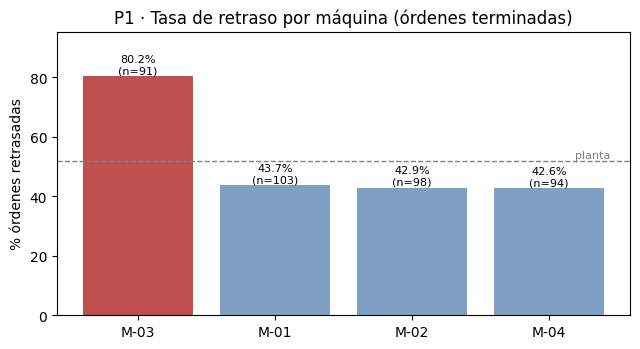

In [25]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
colores = ["#c0504d" if i == 0 else "#7f9fc4" for i in range(len(q1))]
ax.bar(q1.index, q1["pct_retrasadas"], color=colores)
for i, (p, n) in enumerate(zip(q1["pct_retrasadas"], q1["ordenes"])):
    ax.text(i, p + 1, f"{p}%\n(n={n})", ha="center", fontsize=8)
ax.axhline(terminadas["retrasada"].mean() * 100, ls="--", color="gray", lw=1)
ax.text(3.45, terminadas["retrasada"].mean() * 100 + 1, "planta", fontsize=8, color="gray", ha="right")
ax.set_ylabel("% órdenes retrasadas"); ax.set_ylim(0, q1["pct_retrasadas"].max() + 15)
ax.set_title("P1 · Tasa de retraso por máquina (órdenes terminadas)")
plt.tight_layout(); plt.savefig("img/p1_retraso_por_maquina.png", dpi=150); plt.show()

### Pregunta 2 — ¿Cuánto pesan la falta de materia prima y las paradas largas en el retraso?
*Filtro:* órdenes terminadas con disponibilidad de materia prima conocida (se excluye `Sin dato`).
*Agregación:* días de retraso promedio y % retrasadas por combinación de **materia prima (Sí/No)** y
**parada (≥ 4 h vs < 4 h)**.

In [26]:
# --- pandas
base = terminadas[terminadas["mp_disponible"] != "Sin dato"].copy()
base["parada"] = np.where(base["horas_parada"] >= 4, "Larga (≥4 h)", "Corta (<4 h)")
q2 = (base.groupby(["mp_disponible", "parada"])
      .agg(ordenes=("id_orden", "count"),
           pct_retrasadas=("retrasada", lambda s: round(s.mean() * 100, 1)),
           dias_retraso_prom=("dias_retraso", lambda s: round(s.mean(), 2)))
      .reset_index())
q2

,mp_disponible,parada,ordenes,pct_retrasadas,dias_retraso_prom
0,No,Corta (<4 h),41,85.4,1.71
1,No,Larga (≥4 h),19,94.7,3.42
2,Sí,Corta (<4 h),239,33.5,0.06
3,Sí,Larga (≥4 h),79,79.7,1.68


In [27]:
# --- SQL
sql_q2 = '''
SELECT o.mp_disponible,
       CASE WHEN o.horas_parada >= 4 THEN 'Larga (≥4 h)' ELSE 'Corta (<4 h)' END AS parada,
       COUNT(*)                            AS ordenes,
       ROUND(100.0 * AVG(o.retrasada), 1)  AS pct_retrasadas,
       ROUND(AVG(o.dias_retraso), 2)       AS dias_retraso_prom
FROM orden_produccion o
WHERE o.fecha_fin_real IS NOT NULL AND o.mp_disponible <> 'Sin dato'
GROUP BY o.mp_disponible, parada
ORDER BY o.mp_disponible, parada;
'''
res_q2 = pd.read_sql(sql_q2, con)
assert np.allclose(res_q2["dias_retraso_prom"].values, q2.sort_values(["mp_disponible", "parada"])["dias_retraso_prom"].values)
res_q2

,mp_disponible,parada,ordenes,pct_retrasadas,dias_retraso_prom
0,No,Corta (<4 h),41,85.4,1.71
1,No,Larga (≥4 h),19,94.7,3.42
2,Sí,Corta (<4 h),239,33.5,0.06
3,Sí,Larga (≥4 h),79,79.7,1.68


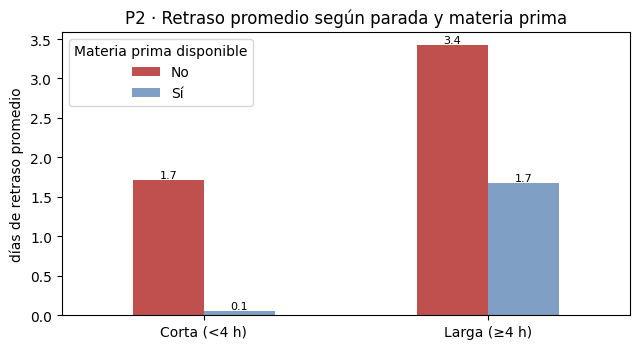

In [28]:
piv = q2.pivot(index="parada", columns="mp_disponible", values="dias_retraso_prom").loc[["Corta (<4 h)", "Larga (≥4 h)"]]
ax = piv.plot(kind="bar", figsize=(6.5, 3.6), color={"Sí": "#7f9fc4", "No": "#c0504d"}, rot=0)
ax.set_xlabel(""); ax.set_ylabel("días de retraso promedio"); ax.legend(title="Materia prima disponible")
ax.set_title("P2 · Retraso promedio según parada y materia prima")
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f", fontsize=8)
plt.tight_layout(); plt.savefig("img/p2_retraso_materia_prima_parada.png", dpi=150); plt.show()

## 7. Hallazgos

In [29]:
mejor = q1.iloc[0]; resto = terminadas[terminadas["maquina"] != q1.index[0]]["retrasada"].mean() * 100
sin_mp = base[base["mp_disponible"] == "No"]["dias_retraso"].mean()
con_mp = base[base["mp_disponible"] == "Sí"]["dias_retraso"].mean()
peor = q2.sort_values("dias_retraso_prom", ascending=False).iloc[0]
mejor_q2 = q2.sort_values("dias_retraso_prom").iloc[0]
print(f"P1 · {q1.index[0]} tiene {mejor['pct_retrasadas']}% de órdenes retrasadas "
      f"({mejor['dias_retraso_prom']} días en promedio) vs {resto:.1f}% en las otras tres máquinas juntas.")
print(f"P2 · Sin materia prima el retraso promedio es {sin_mp:.1f} días vs {con_mp:.1f} con materia prima. "
      f"El peor grupo es '{peor['mp_disponible']} MP + parada {peor['parada']}' ({peor['dias_retraso_prom']} días); "
      f"el mejor, '{mejor_q2['mp_disponible']} MP + parada {mejor_q2['parada']}' ({mejor_q2['dias_retraso_prom']} días).")

P1 · M-03 tiene 80.2% de órdenes retrasadas (1.89 días en promedio) vs 43.1% en las otras tres máquinas juntas.
P2 · Sin materia prima el retraso promedio es 2.2 días vs 0.5 con materia prima. El peor grupo es 'No MP + parada Larga (≥4 h)' (3.42 días); el mejor, 'Sí MP + parada Corta (<4 h)' (0.06 días).


**Lectura.** (1) La máquina más antigua de la planta concentra de lejos la mayor tasa de retraso, lo que sugiere
priorizarla en el plan de mantenimiento. (2) La falta de materia prima y las paradas largas se **acumulan**: las órdenes
que tienen ambos problemas son las que más se atrasan, por lo que asegurar el abastecimiento y reducir paradas son
palancas preventivas concretas para el modelo de riesgo del Corte 1.
**Salvedades:** los datos son sintéticos (el patrón fue diseñado para ilustrar el método) y la asociación observada no
prueba causalidad.